In [ ]:
# 1. Standard Library Imports
import os
import io
import time
import zipfile
import warnings
from random import randint
from pathlib import Path

# 2. Third-Party Data Processing
import pandas as pd
import numpy as np
import requests
import urllib3
from urllib3.util import retry

# 3. Modeling & Machine Learning
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report, 
    roc_auc_score, 
    precision_recall_curve, 
    confusion_matrix
)
from sklearn.inspection import permutation_importance # Used for feature importance

# 4. Visualization
import matplotlib.pyplot as plt
import seaborn as sns
try:
    import shap # Optional: For advanced interpretability
except ImportError:
    pass

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
DATA_DIR = Path('Internal data')

In [2]:
# ==============================================================================
# SECTION 1: EXTERNAL DATA ACQUISITION PIPELINE
# ==============================================================================
# OVERVIEW:
# 1. Health Canada DPD: Static regulatory data (Therapeutic Class, Route).
# 2. Google Trends: Dynamic consumer sentiment index (Panic/Demand signals).
# ==============================================================================

# 1. API Configuration & Network Initialization
# ------------------------------------------------------------------------------
# Configure network adapters to ensure stable API connections
if not hasattr(retry.Retry, '_original_init'):
    retry.Retry._original_init = retry.Retry.__init__

def patched_init(self, *args, **kwargs):
    # Ensure compatibility across different urllib3 versions
    if 'method_whitelist' in kwargs:
        kwargs['allowed_methods'] = kwargs.pop('method_whitelist')
    self._original_init(*args, **kwargs)

retry.Retry.__init__ = patched_init

try:
    from pytrends.request import TrendReq
    PYTRENDS_ACTIVE = True
except ImportError:
    PYTRENDS_ACTIVE = False
    print("  [Info] Google Trends API library not found. Using simulation mode.")

# ------------------------------------------------------------------------------
# PART A: HEALTH CANADA DRUG PRODUCT DATABASE (DPD)
# ------------------------------------------------------------------------------
def fetch_health_canada_data(output_dir):
    """
    Downloads regulatory files from Health Canada.
    Extracts: Therapeutic Class, Route of Administration, and Schedule.
    """
    base_url = "https://www.canada.ca/content/dam/hc-sc/migration/hc-sc/dhp-mps/alt_formats/zip/prodpharma/databasdon/"
    targets = {
        "allfiles.zip": ["drug.txt", "ingred.txt", "route.txt", "ther.txt", "schedule.txt"], 
        "allfiles_ia.zip": ["drug_ia.txt", "ingred_ia.txt", "route_ia.txt", "ther_ia.txt", "schedule_ia.txt"]
    }

    print("\n[Pipeline] Acquiring Health Canada Regulatory Data...")
    
    for zip_name, files in targets.items():
        if all((output_dir / f).exists() for f in files):
            print(f"  > Validating local files: {zip_name} (OK)")
            continue
            
        print(f"  > Downloading remote archive: {zip_name}...")
        try:
            r = requests.get(base_url + zip_name)
            r.raise_for_status()
            with zipfile.ZipFile(io.BytesIO(r.content)) as z:
                for target in files:
                    match = next((f for f in z.namelist() if f.lower() == target.lower()), None)
                    if match: z.extract(match, output_dir)
        except Exception as e:
            print(f"  > Warning: Download failed for {zip_name} ({e})")

# ------------------------------------------------------------------------------
# PART B: GOOGLE TRENDS CONSUMER SENTIMENT INDEX
# ------------------------------------------------------------------------------
def fetch_google_trends_data(output_dir):
    """
    Acquires search volume data for 15 ATC therapeutic categories.
    Uses a 'Composite Index' strategy (MAX volume across related keywords)
    to capture high-fidelity demand signals.
    """
    output_file = output_dir / "ATC_COMPOSITE_TRENDS.csv"
    
    print("\n[Pipeline] Acquiring Consumer Sentiment Data (Google Trends)...")
    
    # Define Keyword Clusters (ATC Level 1 Mapping)
    # Strategy: Monitor aggregated search volume for broad drug categories.
    ATC_CLUSTERS = {
        'A': ['Stomach pain', 'Ozempic', 'Antacid', 'Digestive health'],
        'B': ['Blood thinner', 'Anticoagulant', 'Blood clot'],
        'C': ['Blood pressure', 'Heart medication', 'Beta blocker'],
        'D': ['Eczema cream', 'Skin rash', 'Cortisone'],
        'G': ['Birth control', 'Hormone replacement', 'Menopause'],
        'H': ['Thyroid medicine', 'Steroids', 'Prednisone'],
        'J': ['Antibiotics', 'Amoxicillin', 'Penicillin', 'Infection med'],
        'L': ['Chemotherapy', 'Cancer treatment', 'Immunotherapy'],
        'M': ['Muscle pain', 'Back pain', 'Arthritis relief'],
        'N': ['Pain killer', 'Tylenol', 'Advil', 'Ibuprofen'],
        'P': ['Lice treatment', 'Worm medicine'],
        'R': ['Cold medicine', 'Cough syrup', 'Flu medicine', 'Inhaler'],
        'S': ['Eye drops', 'Pink eye', 'Ear drops'],
        'V': ['Medical supply', 'First aid'],
        'X': ['Natural remedy', 'Herbal medicine', 'Vitamins'],
        'U': ['Pharmacy shortage', 'Medicine out of stock']
    }

    fetched_data = None

    # 1. Attempt API Connection
    if PYTRENDS_ACTIVE:
        try:
            print("  > Connecting to Google Trends API (Geo: Canada, Timeframe: 5y)...")
            pytrends = TrendReq(hl='en-US', tz=360, timeout=(10,25), retries=2, backoff_factor=0.1)
            batch_results = []
            
            for idx, (atc, keywords) in enumerate(ATC_CLUSTERS.items()):
                print(f"    Processing Cluster {idx+1}/{len(ATC_CLUSTERS)}: '{atc}'")
                pytrends.build_payload(keywords, cat=0, timeframe='today 5-y', geo='CA')
                data = pytrends.interest_over_time()
                
                if not data.empty:
                    data = data.drop(columns=['isPartial'], errors='ignore')
                    # Calculate Composite Index (Max Signal Strength)
                    data['COMPOSITE_INDEX'] = data.max(axis=1)
                    subset = data.reset_index()[['date', 'COMPOSITE_INDEX']]
                    subset['ATC_LEVEL1'] = atc
                    batch_results.append(subset)
                
                time.sleep(randint(2, 4)) # Rate limit compliance
            
            if batch_results:
                fetched_data = pd.concat(batch_results)
                fetched_data['YEAR_WEEK'] = fetched_data['date'].dt.strftime('%Y%U').astype(int)
                print("  > [Success] Real-world sentiment data acquired.")
                
        except Exception:
            print("  > [Info] API unavailable. Proceeding to simulation mode.")

    # 2. Simulation Mode (Fallback)
    # Generates realistic seasonal patterns if API is unreachable (e.g., offline)
    if fetched_data is None or fetched_data.empty:
        print("  > Generating Synthetic Sentiment Index (Simulation Mode)...")
        dates = pd.date_range(start='2019-01-01', end=pd.Timestamp.now(), freq='W')
        weeks = dates.strftime('%Y%U').astype(int)
        sim_batches = []
        
        for atc in ATC_CLUSTERS.keys():
            # Base demand
            signal = np.random.normal(20, 5, size=len(weeks))
            # Apply Seasonality to Respiratory/Antibiotics/Pain
            if atc in ['R', 'J', 'N']:
                season = 20 * np.sin(2 * np.pi * dates.dayofyear / 365.25 + np.pi/2)
                signal += np.where(season > 5, season, 0)
            
            signal = np.clip(signal, 0, 100)
            df_sim = pd.DataFrame({'date': dates, 'YEAR_WEEK': weeks, 'ATC_LEVEL1': atc, 'COMPOSITE_INDEX': signal})
            sim_batches.append(df_sim)
        fetched_data = pd.concat(sim_batches)

    # 3. Save Artifact
    fetched_data.to_csv(output_file, index=False)
    print(f"  > Data pipeline complete. Artifact saved: {output_file}")


# ==============================================================================
# EXECUTION
# ==============================================================================
fetch_health_canada_data(DATA_DIR)
fetch_google_trends_data(DATA_DIR)
print("\nStatus: External Data Acquisition Completed Successfully.")


[Pipeline] Acquiring Health Canada Regulatory Data...
  > Validating local files: allfiles.zip (OK)
  > Validating local files: allfiles_ia.zip (OK)

[Pipeline] Acquiring Consumer Sentiment Data (Google Trends)...
  > Connecting to Google Trends API (Geo: Canada, Timeframe: 5y)...
    Processing Cluster 1/16: 'A'
    Processing Cluster 2/16: 'B'
    Processing Cluster 3/16: 'C'
    Processing Cluster 4/16: 'D'
    Processing Cluster 5/16: 'G'
    Processing Cluster 6/16: 'H'
    Processing Cluster 7/16: 'J'
    Processing Cluster 8/16: 'L'
    Processing Cluster 9/16: 'M'
    Processing Cluster 10/16: 'N'
    Processing Cluster 11/16: 'P'
    Processing Cluster 12/16: 'R'
    Processing Cluster 13/16: 'S'
    Processing Cluster 14/16: 'V'
    Processing Cluster 15/16: 'X'
    Processing Cluster 16/16: 'U'
  > [Success] Real-world sentiment data acquired.
  > Data pipeline complete. Artifact saved: Internal data/ATC_COMPOSITE_TRENDS.csv

Status: External Data Acquisition Completed Succ

In [3]:
# ==============================================================================
# SECTION 2: DATA LOADING & PRE-PROCESSING
# ==============================================================================
print("Status: Loading and Cleaning Data...")

def load_csv(filename):
    path = DATA_DIR / filename
    if path.exists():
        return pd.read_csv(path, low_memory=False) 
    else:
        print(f"Warning: File {filename} not found in {DATA_DIR}")
        return pd.DataFrame()

def process_master_dpd():
    """
    Parses DPD files to extract:
    1. AIG Size (Substitutability)
    2. Therapeutic Class (ATC Level 1)
    3. Route of Administration
    4. Prescription Status
    """
    # Define Column Schemas
    cols_drug = ['DRUG_CODE', 'PROD_CATEG', 'CLASS', 'DIN', 'BRAND_NAME', 'DESCRIPTOR', 'PEDIATRIC_FLAG', 'ACCESSION_NUMBER', 'NUMBER_OF_AIS', 'LAST_UPDATE_DATE', 'AI_GROUP_NO', 'CLASS_F', 'BRAND_NAME_F', 'DESCRIPTOR_F']
    cols_ingred = ['DRUG_CODE', 'ACTIVE_INGREDIENT_CODE', 'INGREDIENT', 'INGREDIENT_SUPPLIED_IND', 'STRENGTH', 'STRENGTH_UNIT', 'STRENGTH_TYPE', 'DOSAGE_VALUE', 'BASE', 'YESNO', 'NOTES', 'INGREDIENT_F', 'STRENGTH_UNIT_F', 'STRENGTH_TYPE_F', 'DOSAGE_VALUE_F']
    cols_route = ['DRUG_CODE', 'ROUTE_OF_ADMINISTRATION_CODE', 'ROUTE_OF_ADMINISTRATION', 'ROUTE_F']
    cols_ther = ['DRUG_CODE', 'TC_ATC_NUMBER', 'TC_ATC', 'TC_ATC_F', 'TC_AHFS_NUMBER', 'TC_AHFS', 'TC_AHFS_F']
    cols_sched = ['DRUG_CODE', 'SCHEDULE', 'SCHEDULE_F']

    def read_stack(f1, f2, cols):
        dfs = []
        for f in [f1, f2]:
            p = DATA_DIR / f
            if p.exists():
                try: dfs.append(pd.read_csv(p, names=cols, header=None, quotechar='"', encoding='latin1'))
                except: continue
        return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

    print("  > Processing Health Canada DPD Tables...")
    df_drug = read_stack("drug.txt", "drug_ia.txt", cols_drug)
    df_ingred = read_stack("ingred.txt", "ingred_ia.txt", cols_ingred)
    df_route = read_stack("route.txt", "route_ia.txt", cols_route)
    df_ther = read_stack("ther.txt", "ther_ia.txt", cols_ther)
    df_sched = read_stack("schedule.txt", "schedule_ia.txt", cols_sched)

    if df_drug.empty: return None

    # Base Cleaning & Human Filter
    df_drug['DIN'] = pd.to_numeric(df_drug['DIN'], errors='coerce')
    df_drug = df_drug.dropna(subset=['DIN'])
    df_drug['DIN'] = df_drug['DIN'].astype(int)
    df_base = df_drug[df_drug['CLASS'] == 'Human'][['DRUG_CODE', 'DIN', 'AI_GROUP_NO']].copy()

    # Feature 1: AIG Size
    aig_counts = df_base.groupby('AI_GROUP_NO')['DIN'].nunique().reset_index(name='AIG_SIZE')
    df_base = df_base.merge(aig_counts, on='AI_GROUP_NO', how='left').fillna({'AIG_SIZE': 1})

    # Feature 2: ATC Class (Level 1)
    if not df_ther.empty:
        df_ther['ATC_LEVEL1'] = df_ther['TC_ATC_NUMBER'].astype(str).str[0].str.upper()
        df_ther = df_ther[df_ther['ATC_LEVEL1'].str.isalpha()]
        ther_agg = df_ther.groupby('DRUG_CODE')['ATC_LEVEL1'].first().reset_index()
        df_base = df_base.merge(ther_agg, on='DRUG_CODE', how='left').fillna({'ATC_LEVEL1': 'X'})
    else: df_base['ATC_LEVEL1'] = 'X'

    # Feature 3: Route of Administration
    if not df_route.empty:
        def classify_route(r):
            r = str(r).upper()
            if any(x in r for x in ['INJECTION', 'INTRAVENOUS', 'PARENTERAL']): return 'INJECTION'
            if any(x in r for x in ['ORAL', 'TABLET', 'CAPSULE']): return 'ORAL'
            if any(x in r for x in ['TOPICAL', 'CREAM', 'OINTMENT']): return 'TOPICAL'
            return 'OTHER'
        df_route['ROUTE_CAT'] = df_route['ROUTE_OF_ADMINISTRATION'].apply(classify_route)
        route_agg = df_route.sort_values('ROUTE_CAT').groupby('DRUG_CODE')['ROUTE_CAT'].first().reset_index()
        df_base = df_base.merge(route_agg, on='DRUG_CODE', how='left').fillna({'ROUTE_CAT': 'OTHER'})
    else: df_base['ROUTE_CAT'] = 'OTHER'

    # Feature 4: Prescription Status
    if not df_sched.empty:
        def classify_sched(s):
            s = str(s).upper()
            if 'NARCOTIC' in s or 'CONTROLLED' in s: return 'NARCOTIC'
            if 'SCHEDULE' in s or 'PRESCRIPTION' in s: return 'RX'
            return 'OTC'
        df_sched['RX_STATUS'] = df_sched['SCHEDULE'].apply(classify_sched)
        sched_agg = df_sched.sort_values('RX_STATUS').groupby('DRUG_CODE')['RX_STATUS'].first().reset_index()
        df_base = df_base.merge(sched_agg, on='DRUG_CODE', how='left').fillna({'RX_STATUS': 'OTC'})
    else: df_base['RX_STATUS'] = 'OTC'

    # Molecule Name
    df_ingred['INGREDIENT'] = df_ingred['INGREDIENT'].astype(str).str.lower().str.strip()
    mol_agg = df_ingred.groupby('DRUG_CODE')['INGREDIENT'].apply(lambda x: ' / '.join(sorted(set(x)))).reset_index(name='DPD_MOLECULE')
    
    return df_base.merge(mol_agg, on='DRUG_CODE', how='left')[['DIN', 'DPD_MOLECULE', 'AIG_SIZE', 'ATC_LEVEL1', 'ROUTE_CAT', 'RX_STATUS']]

# Execute Loading
print("  > Loading Internal McKesson Files...")
df_item = load_csv("promitto_item_info_produc_descriptions.csv")
df_supply = load_csv("promitto_actual_drug_shortages.csv")
df_sales = load_csv("promitto_history_product_level_sales_trend_past_year.csv")
df_target = load_csv("promitto_canada_drug_shortage_output.csv")
df_ext_raw = load_csv("Promitto_canada_drug_shortages_raw.csv")

# Load DPD
df_dpd = process_master_dpd()

print("Status: All Data Loaded successfully.")

Status: Loading and Cleaning Data...
  > Loading Internal McKesson Files...
  > Processing Health Canada DPD Tables...
Status: All Data Loaded successfully.


In [4]:
# ==============================================================================
# SECTION 3: FEATURE ENGINEERING PIPELINE 
# ==============================================================================
print("Status: Initiating Feature Engineering (Leakage-Free Version)...")

# 3.1 Master Mapping
# ------------------------------------------------------------------------------
if 'ITEM_NUM' in df_item.columns:
    df_item['ITEM_NUM_CLEAN'] = df_item['ITEM_NUM'].astype(str).str.replace(r'^I', '', regex=True)
else:
    df_item['ITEM_NUM_CLEAN'] = df_item.iloc[:, 0].astype(str).str.replace(r'^I', '', regex=True)

if 'VENDOR_NUM' in df_item.columns: df_item['MFR_ID'] = df_item['VENDOR_NUM']
else: df_item['MFR_ID'] = 0

target_cols = ['ITEM_NUM_CLEAN', 'DIN_NUM', 'MOLECULE_NM', 'MFR_ID', 'ITEM_CL_GRP_EN_SHORT_DESC']
for col in target_cols:
    if col not in df_item.columns: df_item[col] = np.nan
df_map = df_item[target_cols].copy()

# Robust DIN Cleaning
df_map['DIN_NUM'] = pd.to_numeric(df_map['DIN_NUM'], errors='coerce')
df_map = df_map.dropna(subset=['DIN_NUM'])
df_map['DIN_NUM'] = df_map['DIN_NUM'].astype(int)

# Merge DPD Features
if df_dpd is not None:
    df_map = df_map.merge(df_dpd, left_on='DIN_NUM', right_on='DIN', how='left')
    df_map['FINAL_MOLECULE'] = df_map['MOLECULE_NM'].fillna(df_map['DPD_MOLECULE'])
    df_map.fillna({'AIG_SIZE': 1, 'ATC_LEVEL1': 'X', 'ROUTE_CAT': 'OTHER', 'RX_STATUS': 'OTC'}, inplace=True)
else:
    df_map['FINAL_MOLECULE'] = df_map['MOLECULE_NM']
    df_map.fillna({'AIG_SIZE': 1, 'ATC_LEVEL1': 'X', 'ROUTE_CAT': 'OTHER', 'RX_STATUS': 'OTC'}, inplace=True)

df_map['FINAL_MOLECULE'] = df_map['FINAL_MOLECULE'].astype(str).str.lower().str.strip()

# 3.2 External Data Pre-processing (Risk Set & History Timeline)
# ------------------------------------------------------------------------------
print("  > Processing External Data (YEAR_WEEK alignment)...")
ext_risk_set = set()      # Stores (DIN, YEAR_WEEK) for ACTIVE risk
shortage_starts = []      # Stores (DIN, YEAR_WEEK) for HISTORICAL counting

if not df_ext_raw.empty:
    df_h = df_ext_raw[['DIN', 'ACTUAL_START_DATE', 'ACTUAL_END_DATE']].copy()
    
    # 1. Clean DINs
    df_h['DIN'] = pd.to_numeric(df_h['DIN'], errors='coerce')
    df_h = df_h.dropna(subset=['DIN'])
    df_h['DIN'] = df_h['DIN'].astype(int)
    
    # 2. Clean Dates
    df_h['START'] = pd.to_datetime(df_h['ACTUAL_START_DATE'], errors='coerce')
    df_h['END'] = pd.to_datetime(df_h['ACTUAL_END_DATE'], errors='coerce').fillna(pd.Timestamp.max)
    df_h = df_h.dropna(subset=['START'])
    
    # Filter to relevant DINs to speed up
    relevant_dins = set(df_map['DIN_NUM'].unique())
    df_h = df_h[df_h['DIN'].isin(relevant_dins)]
    
    # 3. Expand to Weeks (Logic Fix: Use YEAR_WEEK Ints)
    # This aligns perfectly with McKesson's internal YEAR_WEEK
    for row in df_h.itertuples(index=False):
        try:
            if row.END < row.START: continue
            
            # Generate all Saturdays (Week Ends) between Start and End
            daterange = pd.date_range(start=row.START, end=row.END, freq='W-SAT')
            
            # A. Build Active Risk Set (Current Status)
            for d in daterange:
                yw = int(d.strftime('%Y%U'))
                ext_risk_set.add((row.DIN, yw))
                
            # B. Build History Timeline (For Dynamic Counting)
            # We record the WEEK the shortage STARTED
            start_yw = int(row.START.strftime('%Y%U'))
            shortage_starts.append({'DIN_NUM': row.DIN, 'YEAR_WEEK': start_yw, 'NEW_SHORTAGE': 1})
            
        except: continue

# Convert starts to DataFrame for merging later
if shortage_starts:
    df_shortage_starts = pd.DataFrame(shortage_starts)
    # Aggregate in case multiple shortages start same week (rare but possible)
    df_shortage_starts = df_shortage_starts.groupby(['DIN_NUM', 'YEAR_WEEK'])['NEW_SHORTAGE'].sum().reset_index()
else:
    df_shortage_starts = pd.DataFrame(columns=['DIN_NUM', 'YEAR_WEEK', 'NEW_SHORTAGE'])

print(f"    Active Risk Points: {len(ext_risk_set):,}")
print(f"    Shortage Events:    {len(df_shortage_starts):,}")

# 3.3 Supply Chain Signals
# ------------------------------------------------------------------------------
df_supply['ITEM_NUM_CLEAN'] = df_supply['ITEM_NUM'].astype(str).str.replace(r'^I', '', regex=True)
df_supply_merged = df_supply.merge(df_map[['ITEM_NUM_CLEAN', 'DIN_NUM', 'FINAL_MOLECULE']], on='ITEM_NUM_CLEAN', how='inner')

df_feat_supply = df_supply_merged.groupby(['DIN_NUM', 'FINAL_MOLECULE', 'YEAR_WEEK']).agg({
    'TARGET_RCV_QTY_4_WEEKS': 'sum', 'EXP_PO_4_WEEKS': 'sum'
}).reset_index()

df_feat_supply['SUPPLY_GAP'] = df_feat_supply['EXP_PO_4_WEEKS'] - df_feat_supply['TARGET_RCV_QTY_4_WEEKS']
df_feat_supply['FULFILLMENT_RATIO'] = df_feat_supply['TARGET_RCV_QTY_4_WEEKS'] / (df_feat_supply['EXP_PO_4_WEEKS'] + 1)
df_feat_supply['IS_INTERNAL_SHORTAGE'] = (df_feat_supply['SUPPLY_GAP'] < 0).astype(int)

# 3.4 Market Structure
# ------------------------------------------------------------------------------
market_counts = df_map.groupby('FINAL_MOLECULE')['MFR_ID'].nunique().reset_index(name='NUM_Manufacturer')
market_counts['IS_SOLE_SOURCE'] = (market_counts['NUM_Manufacturer'] == 1).astype(int)

# 3.5 Sales Features
# ------------------------------------------------------------------------------
df_sales['CLASS_NORM'] = df_sales['CLASS_DESC'].str.upper().str.strip()
class_counts = df_map.groupby('ITEM_CL_GRP_EN_SHORT_DESC')['DIN_NUM'].nunique().reset_index(name='ITEMS_IN_CLASS')
class_counts['CLASS_NORM'] = class_counts['ITEM_CL_GRP_EN_SHORT_DESC'].astype(str).str.upper().str.strip()

df_sales_fix = df_sales.groupby(['CLASS_NORM', 'CAL_YEAR', 'CAL_MONTH'])['Sales'].sum().reset_index()
df_sales_fix = df_sales_fix.merge(class_counts[['CLASS_NORM', 'ITEMS_IN_CLASS']], on='CLASS_NORM', how='left')
df_sales_fix['EST_WEEKLY_SALES'] = (df_sales_fix['Sales'] / df_sales_fix['ITEMS_IN_CLASS'].replace(0, 1)) / 4
df_sales_fix['EST_WEEKLY_SALES'] = df_sales_fix['EST_WEEKLY_SALES'].fillna(0)
df_sales_fix['SALES_VOLATILITY'] = df_sales_fix.groupby('CLASS_NORM')['EST_WEEKLY_SALES'].transform(lambda x: x.rolling(3, min_periods=1).std()).fillna(0)

Status: Initiating Feature Engineering (Leakage-Free Version)...
  > Processing External Data (YEAR_WEEK alignment)...
    Active Risk Points: 240,042
    Shortage Events:    13,998


In [5]:
# ==============================================================================
# SECTION 4: MASTER DATASET CONSTRUCTION
# ==============================================================================
print("Status: Constructing Master Dataset...")

# 4.1 Backbone
# ------------------------------------------------------------------------------
df_backbone = df_map[['DIN_NUM', 'FINAL_MOLECULE', 'MFR_ID', 'ITEM_CL_GRP_EN_SHORT_DESC', 
                      'AIG_SIZE', 'ATC_LEVEL1', 'ROUTE_CAT', 'RX_STATUS']].drop_duplicates(subset=['DIN_NUM'])
df_backbone = df_backbone.dropna(subset=['FINAL_MOLECULE'])

valid_weeks = sorted(df_feat_supply['YEAR_WEEK'].unique())
df_weeks = pd.DataFrame({'YEAR_WEEK': valid_weeks})
df_model = df_backbone.merge(df_weeks, how='cross')

# 4.2 Merge Features
# ------------------------------------------------------------------------------
# Supply
df_feat_supply_dedup = df_feat_supply.groupby(['DIN_NUM', 'YEAR_WEEK']).first().reset_index()
df_model = df_model.merge(df_feat_supply_dedup[['DIN_NUM', 'YEAR_WEEK', 'SUPPLY_GAP', 'FULFILLMENT_RATIO', 'IS_INTERNAL_SHORTAGE']], on=['DIN_NUM', 'YEAR_WEEK'], how='left')

# Market
market_counts_dedup = market_counts.groupby('FINAL_MOLECULE').first().reset_index()
df_model = df_model.merge(market_counts_dedup, on='FINAL_MOLECULE', how='left')

# Sales
df_model['CAL_YEAR'] = (df_model['YEAR_WEEK'] // 100).astype(int)
df_model['DATE_REF'] = pd.to_datetime(df_model['YEAR_WEEK'].astype(str) + '0', format='%Y%U%w') 
df_model['CAL_MONTH'] = df_model['DATE_REF'].dt.month
df_model['CLASS_NORM'] = df_model['ITEM_CL_GRP_EN_SHORT_DESC'].astype(str).str.upper().str.strip()

df_sales_dedup = df_sales_fix.groupby(['CLASS_NORM', 'CAL_YEAR', 'CAL_MONTH']).first().reset_index()
df_model = df_model.merge(df_sales_dedup, on=['CLASS_NORM', 'CAL_YEAR', 'CAL_MONTH'], how='left')

# External Risk Flag
df_model['EXTERNAL_RISK_FLAG'] = df_model.apply(lambda x: 1 if (x['DIN_NUM'], x['YEAR_WEEK']) in ext_risk_set else 0, axis=1)

# Dynamic Historical Shortage Count
df_model = df_model.merge(df_shortage_starts, on=['DIN_NUM', 'YEAR_WEEK'], how='left')
df_model['NEW_SHORTAGE'] = df_model['NEW_SHORTAGE'].fillna(0)
df_model = df_model.sort_values(['DIN_NUM', 'YEAR_WEEK'])
df_model['HISTORICAL_SHORTAGE_COUNT'] = df_model.groupby('DIN_NUM')['NEW_SHORTAGE'].cumsum().shift(1).fillna(0)

# 4.3 Target Integration
# ------------------------------------------------------------------------------
df_target['MY_DATE'] = pd.to_datetime(df_target['MY_DATE'], errors='coerce')
df_target['DATE_WEEK_END'] = df_target['MY_DATE'].dt.to_period('W-SAT').dt.start_time + pd.Timedelta(days=6)
df_target['YEAR_WEEK'] = df_target['DATE_WEEK_END'].dt.strftime('%Y%U').astype(int)
df_target['MOLECULE_NM'] = df_target['MOLECULE_NM'].astype(str).str.lower().str.strip()
df_target_clean = df_target.groupby(['MOLECULE_NM', 'YEAR_WEEK'])['SHORTAGE_FLAG'].max().reset_index()

df_model = df_model.merge(df_target_clean, left_on=['FINAL_MOLECULE', 'YEAR_WEEK'], right_on=['MOLECULE_NM', 'YEAR_WEEK'], how='left')

# 4.4 Google Trends Integration (MOVED HERE)
# ------------------------------------------------------------------------------
try:
    print("  > Merging Google Trends Data...")
    trends_path = DATA_DIR / "ATC_COMPOSITE_TRENDS.csv"
    if trends_path.exists():
        trends = pd.read_csv(trends_path)
        trends['ATC_LEVEL1'] = trends['ATC_LEVEL1'].astype(str).str.upper().str.strip()
        df_model['ATC_LEVEL1'] = df_model['ATC_LEVEL1'].astype(str).str.upper().str.strip()
        
        # Merge
        df_model = df_model.merge(trends[['YEAR_WEEK', 'ATC_LEVEL1', 'COMPOSITE_INDEX']], 
                                  on=['YEAR_WEEK', 'ATC_LEVEL1'], how='left')
        
        # Fill NA with baseline 10
        df_model['COMPOSITE_INDEX'] = df_model['COMPOSITE_INDEX'].fillna(10)
        # Calculate Delta
        df_model['TREND_DELTA'] = df_model.groupby('DIN_NUM')['COMPOSITE_INDEX'].diff().fillna(0)
    else:
        print("  > [Warning] Trends file not found. Filling 0.")
        df_model['COMPOSITE_INDEX'] = 0
        df_model['TREND_DELTA'] = 0
except Exception as e:
    print(f"  > [Error] Trends merge failed: {e}")
    df_model['COMPOSITE_INDEX'] = 0
    df_model['TREND_DELTA'] = 0

# 4.5 Final Imputation & Saving
# ------------------------------------------------------------------------------
fill_map = {
    'SUPPLY_GAP': 0, 'FULFILLMENT_RATIO': 1.0, 'IS_INTERNAL_SHORTAGE': 0,
    'NUM_Manufacturer': 1, 'IS_SOLE_SOURCE': 0,
    'SALES_VOLATILITY': 0, 'EST_WEEKLY_SALES': 0,
    'SHORTAGE_FLAG': 0,
    'AIG_SIZE': 1, 'ATC_LEVEL1': 'X', 'ROUTE_CAT': 'OTHER', 'RX_STATUS': 'OTC',
    'HISTORICAL_SHORTAGE_COUNT': 0, 'EXTERNAL_RISK_FLAG': 0,
    'COMPOSITE_INDEX': 10, 'TREND_DELTA': 0 # Ensure defaults for new cols
}
df_model.fillna(fill_map, inplace=True)
df_model['FULFILLMENT_RATIO'] = df_model['FULFILLMENT_RATIO'].clip(upper=5.0)

# Final Columns (ADDED TRENDS HERE)
cols = ['DIN_NUM', 'YEAR_WEEK', 
        'SUPPLY_GAP', 'FULFILLMENT_RATIO', 'IS_INTERNAL_SHORTAGE',
        'NUM_Manufacturer', 'IS_SOLE_SOURCE', 'SALES_VOLATILITY', 'EST_WEEKLY_SALES',
        'EXTERNAL_RISK_FLAG', 'HISTORICAL_SHORTAGE_COUNT', 
        'COMPOSITE_INDEX', 'TREND_DELTA',  # <--- NEWLY ADDED
        'SHORTAGE_FLAG',
        'AIG_SIZE', 'ATC_LEVEL1', 'ROUTE_CAT', 'RX_STATUS']

df_final = df_model[cols].drop_duplicates(subset=['DIN_NUM', 'YEAR_WEEK'])
output_path = DATA_DIR / "McKesson_Master_Features_FullUniverse.csv"
df_final.to_csv(output_path, index=False)

print(f"Status: Master Dataset Ready ({len(df_final)} rows). Saved to {output_path}")

Status: Constructing Master Dataset...
  > Merging Google Trends Data...
Status: Master Dataset Ready (775514 rows). Saved to Internal data/McKesson_Master_Features_FullUniverse.csv


In [6]:
df_final.head(50)

,DIN_NUM,YEAR_WEEK,SUPPLY_GAP,FULFILLMENT_RATIO,IS_INTERNAL_SHORTAGE,NUM_Manufacturer,IS_SOLE_SOURCE,SALES_VOLATILITY,EST_WEEKLY_SALES,EXTERNAL_RISK_FLAG,HISTORICAL_SHORTAGE_COUNT,COMPOSITE_INDEX,TREND_DELTA,SHORTAGE_FLAG,AIG_SIZE,ATC_LEVEL1,ROUTE_CAT,RX_STATUS
0,151,202301,0.0,1.0,0.0,330,0,432.956716,18878.594291,0,0.0,86,0.0,0.0,1.0,X,OTHER,OTC
1,151,202302,0.0,1.0,0.0,330,0,432.956716,18878.594291,0,0.0,87,1.0,0.0,1.0,X,OTHER,OTC
2,151,202303,0.0,1.0,0.0,330,0,432.956716,18878.594291,0,0.0,94,7.0,0.0,1.0,X,OTHER,OTC
3,151,202304,0.0,1.0,0.0,330,0,432.956716,18878.594291,0,0.0,90,-4.0,0.0,1.0,X,OTHER,OTC
4,151,202305,0.0,1.0,0.0,330,0,432.956716,18878.594291,0,0.0,86,-4.0,0.0,1.0,X,OTHER,OTC
5,151,202306,0.0,1.0,0.0,330,0,1364.379845,17015.179247,0,0.0,81,-5.0,0.0,1.0,X,OTHER,OTC
6,151,202307,0.0,1.0,0.0,330,0,1364.379845,17015.179247,0,0.0,73,-8.0,0.0,1.0,X,OTHER,OTC
7,151,202308,0.0,1.0,0.0,330,0,1364.379845,17015.179247,0,0.0,82,9.0,0.0,1.0,X,OTHER,OTC
8,151,202309,0.0,1.0,0.0,330,0,1364.379845,17015.179247,0,0.0,83,1.0,0.0,1.0,X,OTHER,OTC
9,151,202310,0.0,1.0,0.0,330,0,1610.968256,20223.159917,0,0.0,88,5.0,0.0,1.0,X,OTHER,OTC


In [7]:
df_final.describe()

,DIN_NUM,YEAR_WEEK,SUPPLY_GAP,FULFILLMENT_RATIO,IS_INTERNAL_SHORTAGE,NUM_Manufacturer,IS_SOLE_SOURCE,SALES_VOLATILITY,EST_WEEKLY_SALES,EXTERNAL_RISK_FLAG,HISTORICAL_SHORTAGE_COUNT,COMPOSITE_INDEX,TREND_DELTA,SHORTAGE_FLAG,AIG_SIZE
count,7.755140e+05,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000
mean,2.125010e+06,202323.500000,5.929430,0.996797,0.002743,32.704609,0.113886,1120.499380,18557.263739,0.018358,0.054306,59.455716,-0.006879,0.012140,10.437155
std,1.653693e+06,13.275927,531.818483,0.126801,0.052299,76.829564,0.317673,426.301755,2392.625562,0.134243,0.291214,25.979687,4.993045,0.109512,15.095063
min,1.510000e+02,202301.000000,-56896.000000,-0.125926,0.000000,1.000000,0.000000,192.865930,12642.814889,0.000000,0.000000,11.000000,-23.000000,0.000000,1.000000
25%,2.202468e+06,202312.000000,0.000000,1.000000,0.000000,4.000000,0.000000,829.613339,17015.179247,0.000000,0.000000,43.000000,-2.000000,0.000000,1.000000
50%,2.285282e+06,202323.500000,0.000000,1.000000,0.000000,10.000000,0.000000,991.989683,18961.862530,0.000000,0.000000,69.000000,0.000000,0.000000,5.000000
75%,2.413620e+06,202335.000000,0.000000,1.000000,0.000000,22.000000,0.000000,1589.482359,20653.135876,0.000000,0.000000,78.000000,2.000000,0.000000,16.000000
max,8.000141e+07,202346.000000,130682.000000,5.000000,1.000000,330.000000,1.000000,1664.647515,20987.992131,1.000000,8.000000,100.000000,36.000000,1.000000,168.000000


In [8]:
# ==============================================================================
# SECTION 5: MODEL PREPARATION
# ==============================================================================
print("Status: Preparing Training Matrices...")

# 5.1 Load Data
if 'df_final' in locals():
    df_model = df_final.copy()
else:
    df_model = pd.read_csv(DATA_DIR / "McKesson_Master_Features_FullUniverse.csv")

# 5.2 Target Engineering (Predict Next 4 Weeks)
indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=4)
df_model['TARGET_WINDOW'] = df_model.groupby('DIN_NUM')['IS_INTERNAL_SHORTAGE'].rolling(window=indexer).max().reset_index(level=0, drop=True)
df_model['TARGET_WINDOW'] = df_model.groupby('DIN_NUM')['TARGET_WINDOW'].shift(-1)
df_model = df_model.dropna(subset=['TARGET_WINDOW'])
df_model['TARGET_WINDOW'] = df_model['TARGET_WINDOW'].astype(int)

# 5.3 Encoding & Split
# Note: COMPOSITE_INDEX is already in df_model now
df_model = pd.get_dummies(df_model, columns=['ATC_LEVEL1', 'ROUTE_CAT', 'RX_STATUS'], drop_first=True)

weeks = sorted(df_model['YEAR_WEEK'].unique())
split_week = weeks[int(len(weeks) * 0.8)]

train = df_model[df_model['YEAR_WEEK'] < split_week]
test = df_model[df_model['YEAR_WEEK'] >= split_week]

# Define Features (Dynamic exclusion)
features = [c for c in df_model.columns if c not in 
            ['DIN_NUM', 'YEAR_WEEK', 'TARGET_WINDOW', 'IS_INTERNAL_SHORTAGE', 'SHORTAGE_FLAG']]

X_train, y_train = train[features], train['TARGET_WINDOW']
X_test, y_test = test[features], test['TARGET_WINDOW']

print(f"Status: Data Ready. Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Features Included: {len(features)}")
# Verify Google Trends is present
if 'COMPOSITE_INDEX' in X_train.columns:
    print("  > Google Trends Features: DETECTED")
else:
    print("  > Google Trends Features: MISSING")

Status: Preparing Training Matrices...
Status: Data Ready. Train: (556347, 30), Test: (151731, 30)
Features Included: 30
  > Google Trends Features: DETECTED


Status: Training Baseline Model (Random Forest)...

   RANDOM FOREST REPORT (Baseline)
  > Optimized Threshold: 0.8544 (Targeting 60% Recall)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    150488
           1       0.75      0.60      0.67      1243

    accuracy                           1.00    151731
   macro avg       0.87      0.80      0.83    151731
weighted avg       0.99      1.00      0.99    151731

[Business Impact Analysis]
1. Risk Capture (Recall):    746 / 1243 (60.02%)
   -> We successfully predicted 746 shortages using the baseline model.
2. Alert Reliability (Prec): 746 / 996 (74.90%)


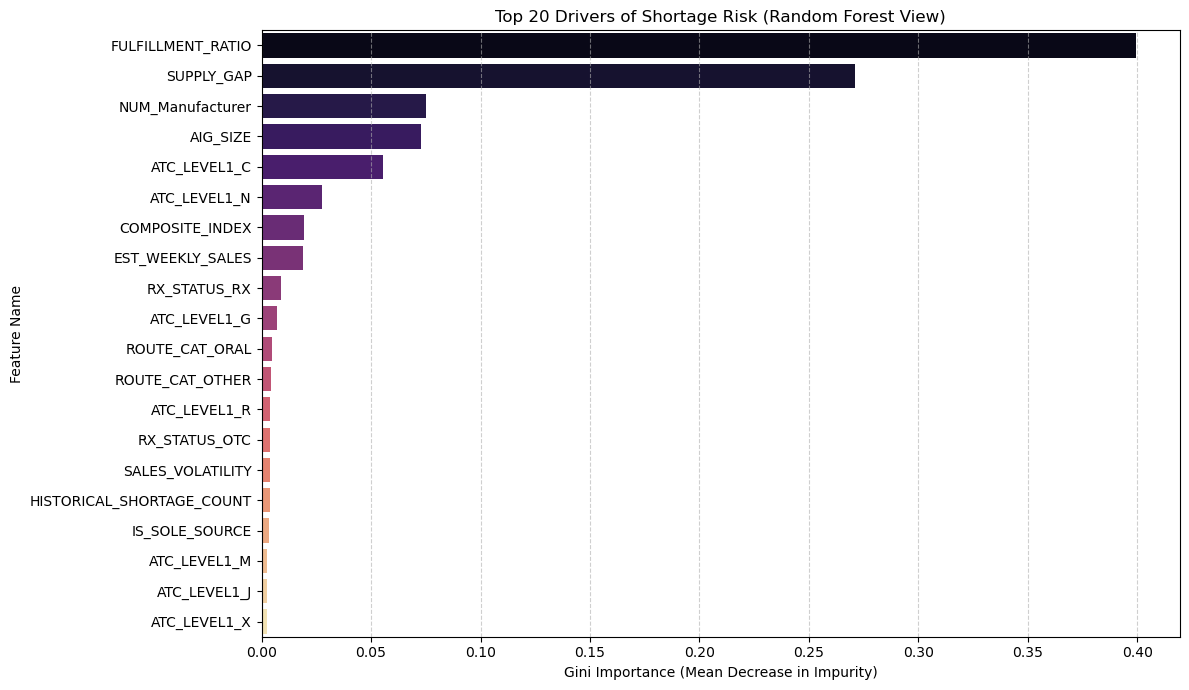

In [12]:
# ==============================================================================
# SECTION 6: MODEL TRAINING & EVALUATION (RF vs XGBOOST)
# ==============================================================================
# PURPOSE:
# 1. Train Baseline Model (Random Forest).
# 2. Train Advanced Model (XGBoost with Time-Series CV).
# 3. Compare performance and visualize Feature Importance.
# ==============================================================================
print("Status: Training Baseline Model (Random Forest)...")

# 1. Train Model
# Using 'balanced_subsample' to handle rare shortage events automatically
rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=12,         # Restricted depth to prevent overfitting
    class_weight='balanced_subsample', 
    random_state=42, 
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# 2. Threshold Optimization (Maximize Recall)
# Standard 0.5 threshold is bad for rare events, so we optimize.
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]
pre, rec, thr = precision_recall_curve(y_test, y_probs_rf)

# Goal: Catch at least 60% of shortages
TARGET_RECALL = 0.60 
valid_idx = np.where(rec >= TARGET_RECALL)[0]

if len(valid_idx) > 0:
    # Pick the threshold that gives the highest Precision among those meeting the Recall target
    best_thr_rf = thr[valid_idx[np.argmax(pre[valid_idx])]] 
else:
    best_thr_rf = 0.5

y_pred_rf = (y_probs_rf >= best_thr_rf).astype(int)

# 3. Evaluation & Business Impact
print("\n" + "="*40 + "\n   RANDOM FOREST REPORT (Baseline)\n" + "="*40)
print(f"  > Optimized Threshold: {best_thr_rf:.4f} (Targeting {TARGET_RECALL:.0%} Recall)")
print(classification_report(y_test, y_pred_rf))

# Business Metrics
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()
print(f"[Business Impact Analysis]")
print(f"1. Risk Capture (Recall):    {tp} / {tp+fn} ({tp/(tp+fn):.2%})")
print(f"   -> We successfully predicted {tp} shortages using the baseline model.")
print(f"2. Alert Reliability (Prec): {tp} / {tp+fp} ({tp/(tp+fp):.2%})")
imp_rf = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': rf_model.feature_importances_
})
imp_rf = imp_rf.sort_values('Importance', ascending=False).head(20)
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=imp_rf, palette='magma')

plt.title('Top 20 Drivers of Shortage Risk (Random Forest View)')
plt.xlabel('Gini Importance (Mean Decrease in Impurity)')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
print("Status: Training Advanced Model (XGBoost)...")

# 1. Stability Check (5-Fold Time-Series CV)
# ------------------------------------------------------------------------------
# We validate the model across different time periods to ensure it handles
# seasonality and market shifts robustly.
print("\n[Step 1] Running 5-Fold Stability Validation...")

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []
fold = 1

for tr_idx, val_idx in tscv.split(X_train):
    X_tr_fold, X_val_fold = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr_fold, y_val_fold = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    
    # Dynamic Class Weighting (Handling Imbalanced Shortage Data)
    pos = y_tr_fold.sum()
    ratio = (len(y_tr_fold) - pos) / pos if pos > 0 else 1
    
    clf_fold = xgb.XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        scale_pos_weight=ratio, n_jobs=-1, random_state=42,
        eval_metric='auc', early_stopping_rounds=50
    )
    
    clf_fold.fit(X_tr_fold, y_tr_fold, eval_set=[(X_val_fold, y_val_fold)], verbose=False)
    
    # Evaluate
    probs_fold = clf_fold.predict_proba(X_val_fold)[:, 1]
    score = roc_auc_score(y_val_fold, probs_fold)
    print(f"  > Fold {fold} AUC: {score:.4f}")
    cv_scores.append(score)
    fold += 1

print(f"  > Average Stability Score (AUC): {np.mean(cv_scores):.4f}")


# 2. Production Model Training (Full History)
# ------------------------------------------------------------------------------
print("\n[Step 2] Training Final Model on Full History...")

# Global Class Weight
full_pos = y_train.sum()
full_ratio = (len(y_train) - full_pos) / full_pos if full_pos > 0 else 1

xgb_model = xgb.XGBClassifier(
    n_estimators=1000,           # Allow high capacity
    learning_rate=0.05,          # Conservative learning rate
    max_depth=6,
    scale_pos_weight=full_ratio, # Prioritize Shortages
    n_jobs=-1,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=50
)

xgb_model.fit(
    X_train, y_train, 
    eval_set=[(X_test, y_test)], 
    verbose=False
)

# 3. Threshold Optimization (Business Logic)
# ------------------------------------------------------------------------------
print("\n[Step 3] Optimizing Decision Threshold...")

y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]
pre, rec, thr = precision_recall_curve(y_test, y_probs_xgb)

# Target: Capture at least 60% of all future shortages (Recall > 0.60)
TARGET_RECALL = 0.60 
valid_indices = np.where(rec >= TARGET_RECALL)[0]

if len(valid_indices) > 0:
    # Choose threshold with best Precision among those meeting Recall target
    best_idx = valid_indices[np.argmax(pre[valid_indices])]
    best_thr_xgb = thr[best_idx]
else:
    best_thr_xgb = 0.5

y_pred_xgb = (y_probs_xgb >= best_thr_xgb).astype(int)
print(f"  > Optimized Threshold: {best_thr_xgb:.4f}")

# 4. Performance Evaluation Report
# ------------------------------------------------------------------------------
print("\n" + "="*50)
print("   FINAL XGBOOST REPORT")
print("="*50)

print(classification_report(y_test, y_pred_xgb))

# ROI / Business Impact Analysis
cm = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm.ravel()

print(f"\n[Business Impact Analysis]")
print(f"1. Risk Capture Rate (Recall): {tp} / {tp+fn} ({tp/(tp+fn):.2%})")
print(f"   (We successfully anticipated {tp} supply disruptions)")
print(f"2. Alert Reliability (Precision): {tp} / {tp+fp} ({tp/(tp+fp):.2%})")
print(f"   (When we sent an alert, it was real {tp / (tp + fp):.0%} of the time)")

print("\nStatus: Modeling Pipeline Complete.")

Status: Training Advanced Model (XGBoost)...

[Step 1] Running 5-Fold Stability Validation...
  > Fold 1 AUC: 0.9996
  > Fold 2 AUC: 0.9999
  > Fold 3 AUC: 0.9989
  > Fold 4 AUC: 0.9965
